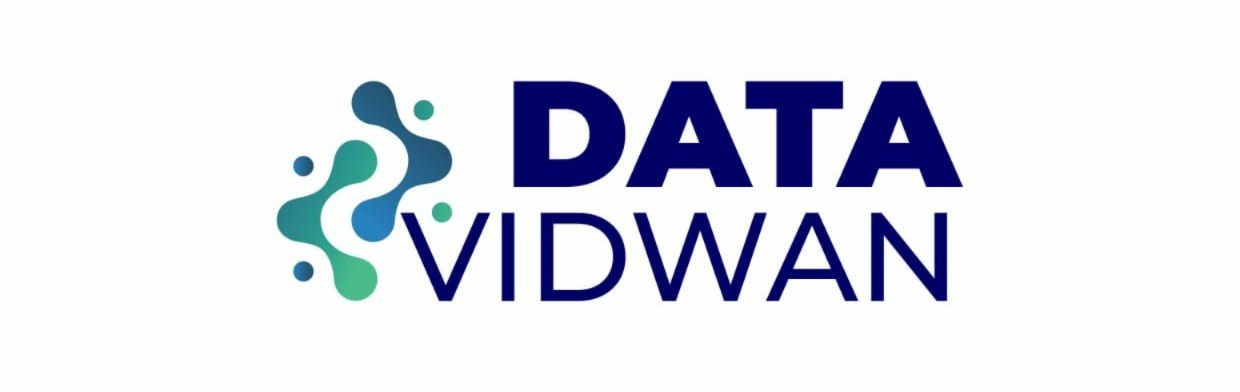

# **What is Artificial Intelligence ?**

Artificial Intelligence (AI) means creating computer systems that can perform tasks which normally require human intelligence.

**Example:**

- Google Maps suggesting the fastest route
- Siri or Alexa understanding your voice
- Facebook detecting faces in photos

**Types of AI**

**1. Narrow AI (Weak AI)**
- AI that is trained for one specific task.
- Example:
  - Google Translate (only language translation)
  - Face recognition in your phone
  - Spam filter in Gmail
- Works well in one area, but cannot do everything.

**2. General AI (Strong AI)**
- AI that can perform any intellectual task like a human.
- Still a future goal, not fully achieved.
Example:
  - A robot that can cook, study, drive and talk like a human.

**3. Super AI**
- AI that will be smarted than humans in all aspects.
- Purely theoretical right now (sci-fi movies show this).
- Example:
  - Jarvis in Iron Man
  - Terminator movies

# **What is Machine Learning ?**

- Machine Learning is a subset of AI.
- It is the science of making computers learn from data and improve automatically without being explicitly programmed.

**Example:**

- If you watch comedy movies on Netflix, it will recommend more comedy movies.
- Gmail automatically puts some emails in the “Spam” folder.
- Amazon suggests products based on what you previously bought.

# **Exploratory Data Analysis (EDA)**

**What is EDA?**

- Exploratory Data Analysis (EDA) is the process of understanding the dataset before applying ML models.

It helps us find:

- Structure of data (rows, columns, datatypes)
- Summary statistics (mean, median, min, max)
- Missing values
- Outliers
- Relationships between variables
- Patterns, trends, correlations

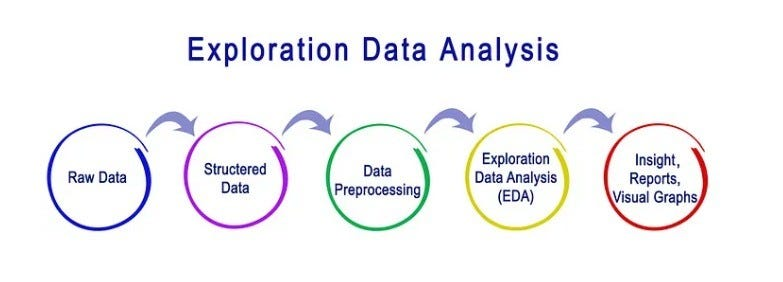

**Types/Methods of EDA**

EDA is usually done in 3 levels:

**1. Univariate Analysis (Single variable at a time)**
- Focus on one column (distribution, frequency).
- Example: Age distribution of passengers.
- Tools: describe(), histograms, boxplots, countplots.

**2. Biravariate Analysis (two variables at a time)**
- Relationship between two variables.
- Example: Age vs Fare, or Sex vs Survival.
- Tools: scatter plots, correlation, boxplots, groupby.

**3. Multivariate Analysis (three or more variables together)**
- Look at combined effect of multiple variables.
- Example: Survival by Gender + Class.
- Tools: heatmaps, pairplots, grouped bar plots.


**Steps of EDA**

- Dataset Overview – shape, head, info, datatypes
- Univariate Analysis – one column distribution
- Bivariate Analysis – relation between two columns
- Multivariate Analysis – patterns among multiple columns
- Missing Values check
- Outliers check

# **1. Univariate Analysis**

- Univariate = analyzing one variable (one column) at a time.

**Goal:** To understand the distribution, range, frequency, and patterns of a single feature.

Types od Variables:

**1. Numerical (Continuous/Discrete)** → Age, Fare, SibSp, Parch


**2. Categorical** → Gender, Embarked, Pclass, Survived


**Load Dataset**

In [1]:
from google.colab import files
uploaded = files.upload()

Saving titanic.csv to titanic.csv


In [2]:
import pandas as pd

# Load Titanic dataset
df = pd.read_csv("titanic.csv")

# Check first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Gender,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**Dataset Overview**

In [3]:
# 1. Shape of dataset (rows, columns)
print("Shape of dataset:", df.shape)

# 2. Column names
print("\nColumn Names:\n", df.columns)

# 3. Data types and null values
print("\nInfo:")
print(df.info())

# 4. Summary statistics (numerical columns only)
print("\nSummary statistics:")
print(df.describe())

Shape of dataset: (891, 12)

Column Names:
 Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Gender', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Gender       891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None

Summary statistics:
       Pass

# **Univariate Analysis (Numerical Variables)**

**1. Age**

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Age', kde=True, bins=30)
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()


NameError: name 'df' is not defined

<Figure size 600x400 with 0 Axes>

**2. Fare**

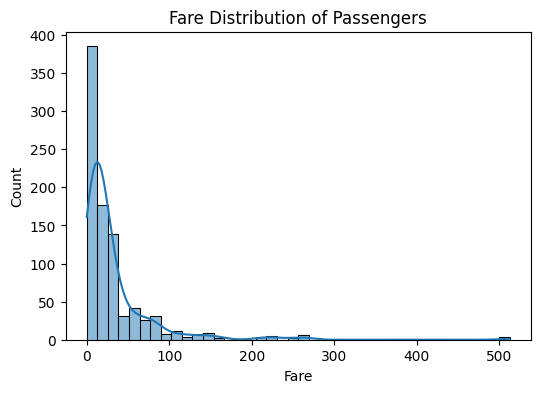

In [5]:
plt.figure(figsize=(6,4))
sns.histplot(data=df, x='Fare', kde=True, bins=40)
plt.title('Fare Distribution of Passengers')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.show()


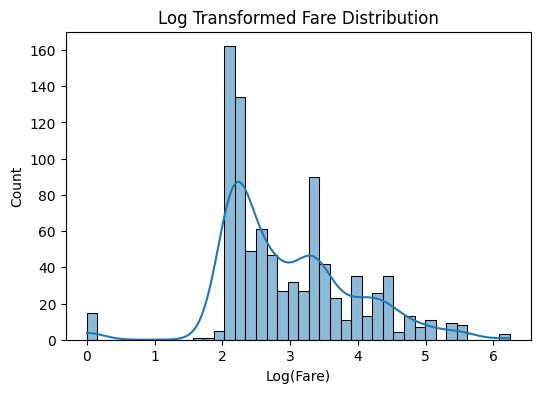

In [6]:
import numpy as np

plt.figure(figsize=(6,4))
sns.histplot(x=np.log1p(df['Fare']), kde=True, bins=40)
plt.title('Log Transformed Fare Distribution')
plt.xlabel('Log(Fare)')
plt.ylabel('Count')
plt.show()

**Problem with original Fare**

- Fare is highly right-skewed
- A few passengers paid very high fares

Because of this:
- Most values are crowded on the left side
- A long tail appears on the right side of the graph

This makes the distribution hard to understand and can affect model performance.

**Why we use log transformation on Fare**

- It reduces skewness
- It compresses very large values
- The data looks more balanced and normal
- Machine learning models learn better and more stably

**Why log1p?**

- Some fare values can be 0
- log1p(x) safely handles zero values and avoids math errors



# **3. SibSp**

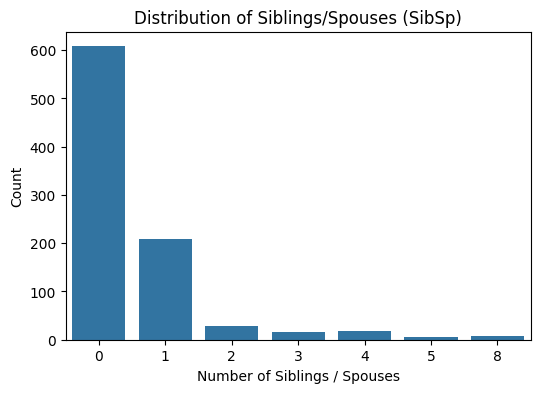

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='SibSp')
plt.title('Distribution of Siblings/Spouses (SibSp)')
plt.xlabel('Number of Siblings / Spouses')
plt.ylabel('Count')
plt.show()


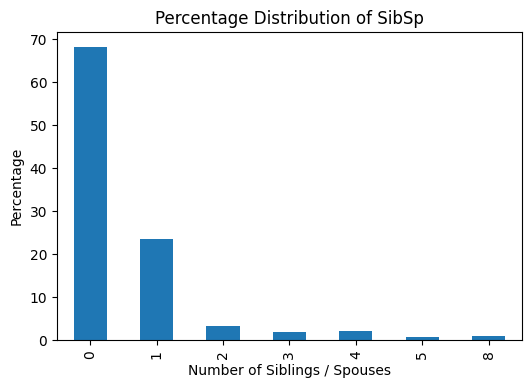

In [8]:
(df['SibSp'].value_counts(normalize=True) * 100).sort_index().plot(kind='bar', figsize=(6,4))
plt.title('Percentage Distribution of SibSp')
plt.xlabel('Number of Siblings / Spouses')
plt.ylabel('Percentage')
plt.show()

- Majority passengers have 0 or 1 sibling/spouse

# **Univariate Analysis (Categorical Variables)**

**Categorical columns in Titanic dataset:**

- Survived (0 = No, 1 = Yes)
- Gender (male, female)
- Pclass (1, 2, 3)

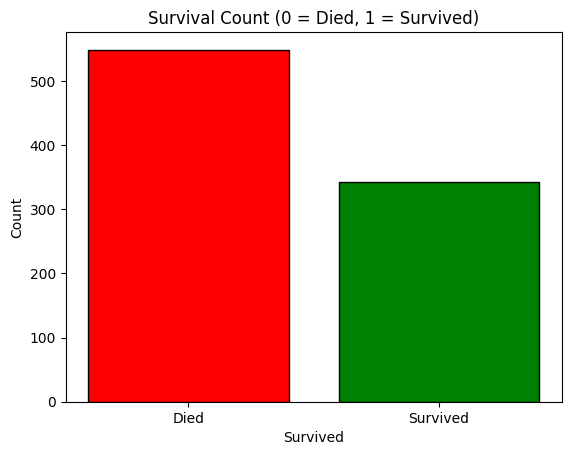

In [9]:
# Count of Survived
survived_counts = df['Survived'].value_counts()

plt.bar(survived_counts.index, survived_counts.values,
        color=['red', 'green'], edgecolor='black')
plt.title("Survival Count (0 = Died, 1 = Survived)")
plt.xlabel("Survived")
plt.ylabel("Count")
plt.xticks([0,1], ['Died', 'Survived'])
plt.show()

**Gender Distribution**

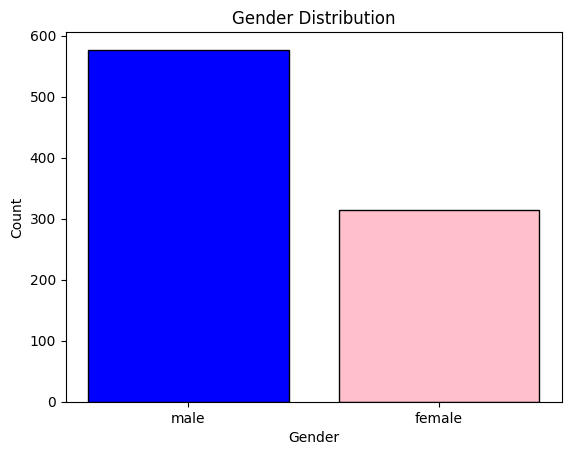

In [10]:
# Count of Gender
sex_counts = df['Gender'].value_counts()

plt.bar(sex_counts.index, sex_counts.values,
        color=['blue', 'pink'], edgecolor='black')
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

**Passenger Class Distribution**

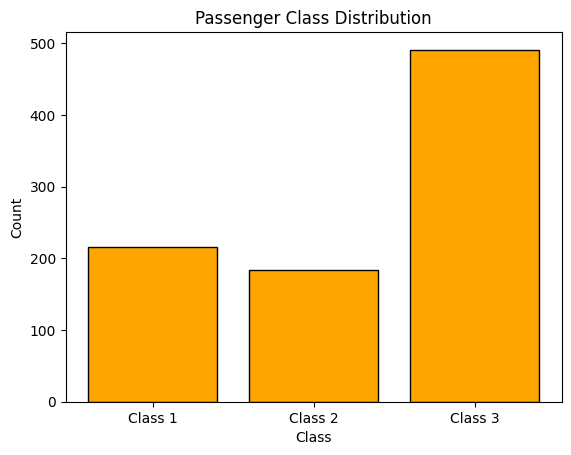

In [11]:
# Count of Pclass
pclass_counts = df['Pclass'].value_counts().sort_index()

plt.bar(pclass_counts.index, pclass_counts.values,
        color='orange', edgecolor='black')
plt.title("Passenger Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([1,2,3], ['Class 1', 'Class 2', 'Class 3'])
plt.show()


# **2. Bivaraite Analysis**

Analyzing the relationship between two variables at the same time.

3 main cases:

- **Numerical vs Numerical** → Scatter plot, Line plot
- **Categorical vs Numerical** → Boxplot, Bar chart (grouped)
- **Categorical vs Categorical** → Stacked bar chart, Crosstab

**1. Numerical vs Numerical**

Age vs Fare

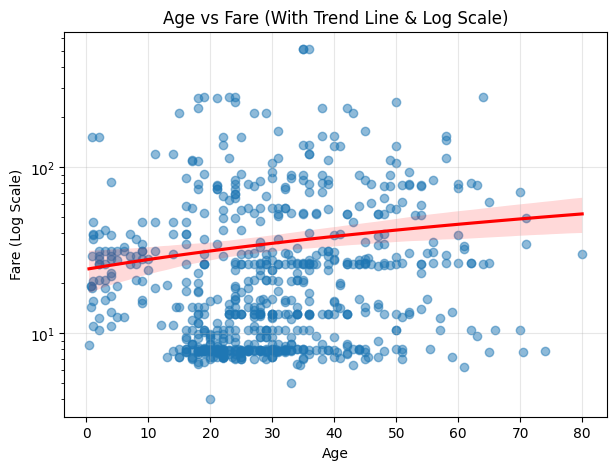

In [15]:
plt.figure(figsize=(7,5))

sns.regplot(
    data=df,
    x='Age',
    y='Fare',
    scatter_kws={'alpha':0.5},
    line_kws={'color':'red'}
)

plt.yscale('log')

plt.title('Age vs Fare (With Trend Line & Log Scale)')
plt.xlabel('Age')
plt.ylabel('Fare (Log Scale)')
plt.grid(alpha=0.3)

plt.show()

**The red regression line shows a slight upward trend.**
- This means fare slightly increases with age.

**However, the slope is very small.**
- So, there is no strong relationship between Age and Fare.

The scatter plot with regression line shows that there is no strong linear relationship between Age and Fare. The log transformation of Fare helps reduce the effect of extreme outliers and provides a clearer visualization of the distribution. Most passengers paid lower fares irrespective of age, while a few extreme fare values are observed across different age groups.


**2. Categorical vs Numerical**

**Survival vs Age**

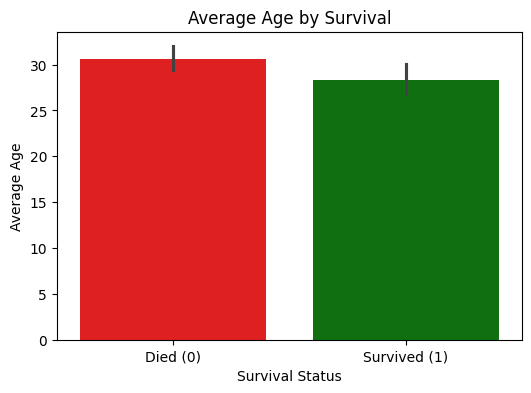

In [19]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x='Survived',
    y='Age',
    hue='Survived',           # yahi add karna hai
    estimator=np.mean,
    palette={0: 'red', 1: 'green'},
    legend=False              # duplicate legend avoid karega
)

plt.title('Average Age by Survival')
plt.xlabel('Survival Status')
plt.ylabel('Average Age')

plt.xticks([0,1], ['Died (0)', 'Survived (1)'])

plt.show()

Xticks are the tick marks and corresponding labels shown on the X-axis of a plot. They define how categories or numerical values are displayed along the horizontal axis.

**instead of displaying just 0 and 1, the graph shows:**
- Died (0)
- Survived (1)

**Pclass vs Fare**

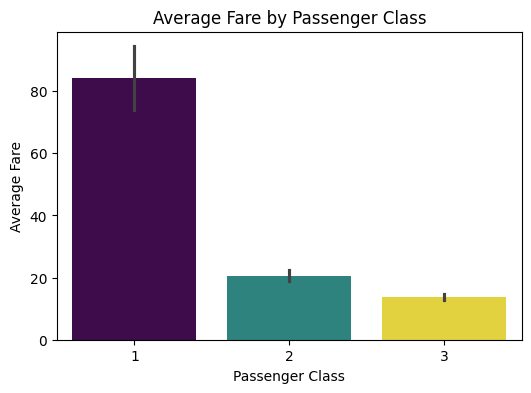

In [20]:
plt.figure(figsize=(6,4))

sns.barplot(
    data=df,
    x='Pclass',
    y='Fare',
    estimator=np.mean,
    hue='Pclass',
    palette='viridis',
    legend=False
)

plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")

plt.show()

- **Estimator:** Defines which statistical measure (mean/median) is used for bar height.
- **Hue:** Splits data into color-based categories.
- **Palette:** Controls the color theme of the plot.

**3. Categorical vs Categorical**

**Gender vs Survival**

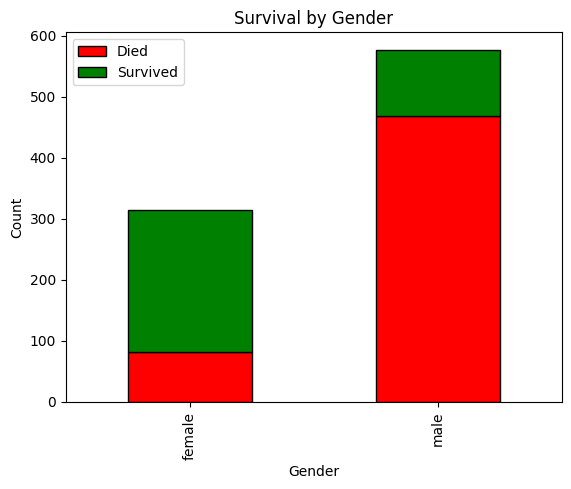

In [ ]:
# Bar chart: Gender vs Survival
survival_by_Gender = pd.crosstab(df['Gender'], df['Survived'])

survival_by_Gender.plot(kind="bar", stacked=True, color=['red','green'], edgecolor='black')
plt.title("Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(["Died", "Survived"])
plt.show()

**Embarked vs Survival**

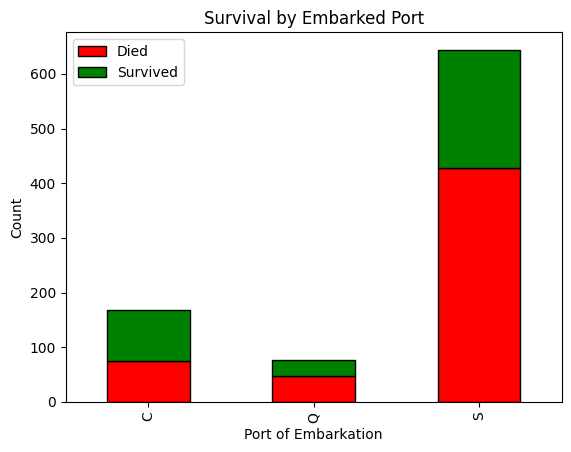

In [ ]:
# Bar chart: Embarked vs Survival
survival_by_embarked = pd.crosstab(df['Embarked'], df['Survived'])

survival_by_embarked.plot(kind="bar", stacked=True, color=['red','green'], edgecolor='black')
plt.title("Survival by Embarked Port")
plt.xlabel("Port of Embarkation")
plt.ylabel("Count")
plt.legend(["Died", "Survived"])
plt.show()

**4. Multivariate Analysis**

- Studying the relationship between 3 or more variables together.

**Survival by Gender & Class**

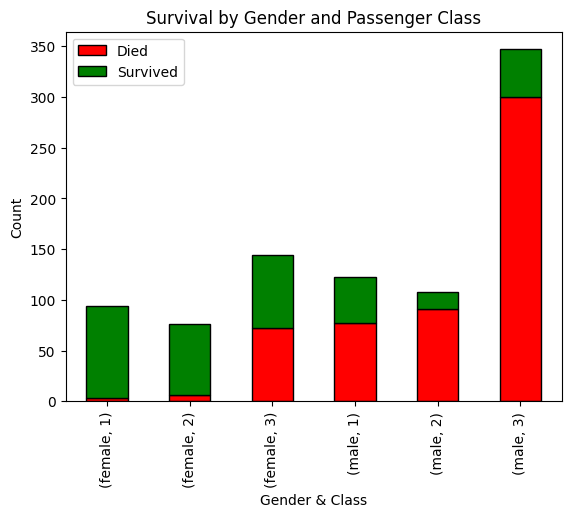

In [ ]:
# Crosstab of Sex & Pclass vs Survival
survival_by_Gender_class = pd.crosstab([df['Gender'], df['Pclass']], df['Survived'])

# Plot grouped bar chart
survival_by_Gender_class.plot(kind="bar", stacked=True, color=['red','green'], edgecolor='black')
plt.title("Survival by Gender and Passenger Class")
plt.xlabel("Gender & Class")
plt.ylabel("Count")
plt.legend(["Died", "Survived"])
plt.show()

**Age vs Fare vs Survival**

**Pclass vs Gender vs Survival (Grouped Bars)**

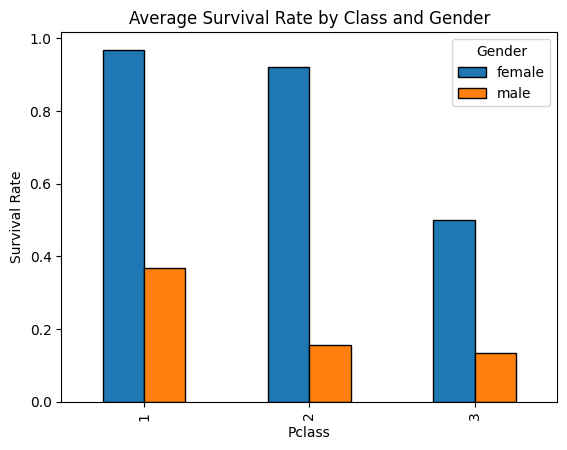

In [ ]:
# Group by Sex and Pclass
group_data = df.groupby(['Pclass', 'Gender'])['Survived'].mean().unstack()

# Plot bar chart
group_data.plot(kind='bar', edgecolor='black')
plt.title("Average Survival Rate by Class and Gender")
plt.xlabel("Pclass")
plt.ylabel("Survival Rate")
plt.show()

# **Handling Missing Values**

**What are Missing Values?**

When some information is not recorded in the dataset.
Example:

  - Age not written for some passengers
  - Embarked place missing for few people

In Pandas, these appear as NaN (Not a Number).

**Why are Missing Values a Problem?**

- ML algorithms can’t work properly with missing data.
- It reduces accuracy.
- It can create bias (wrong predictions).

There are 3 main ways to handle missing values:

**1. Removing Missing Values(Drop)**
- If very few rows/columns have missing values, we can simply remove them.

**2. Filling Missing Values (Imputation)**
- Instead of removing, we replace missing values with some suitable value.

Ways to fill:

- **Mean** → Average of the column (good for numerical data).
- **Median** → Middle value (better when outliers are present).
- **Mode** → Most frequent value (good for categorical data like "Male/Female").
- **Constant value** → Example: fill missing Age with 0 or "Unknown".

**3. Forward Fill / Backward Fill**

- Fill missing values using previous (ffill) or next (bfill) value.
Useful in time series data (e.g., stock prices, weather).

**Checking Missing Values**

**1. Check if any value is missing**

In [ ]:
df.isnull().any()

,0
PassengerId,False
Survived,False
Pclass,False
Name,False
Gender,False
Age,True
SibSp,False
Parch,False
Ticket,False
Fare,False


**2. Count missing values per column**

In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Gender,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


**3. Check total missing values in dataset**

In [ ]:
df.isnull().sum().sum()

np.int64(866)

# **1. Dropping Missing Values**

Check Missing + Drop Rows (Any NaN) — Before/After

In [ ]:
print("=== Missing values (BEFORE) ===")
print(df.isnull().sum())
print("\nShape BEFORE:", df.shape)
print("Total NaNs BEFORE:", df.isnull().sum().sum())

# Drop any row that contains at least one NaN
df_rowdrop = df.dropna()

print("\n=== Missing values (AFTER Row-Drop) ===")
print(df_rowdrop.isnull().sum())
print("\nShape AFTER:", df_rowdrop.shape)
print("Total NaNs AFTER:", df_rowdrop.isnull().sum().sum())

=== Missing values (BEFORE) ===
PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

Shape BEFORE: (891, 12)
Total NaNs BEFORE: 866

=== Missing values (AFTER Row-Drop) ===
PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Shape AFTER: (183, 12)
Total NaNs AFTER: 0


# **Visualize BEFORE vs AFTER (Row-Drop)**

**1) Age Distribution Before row-drop**



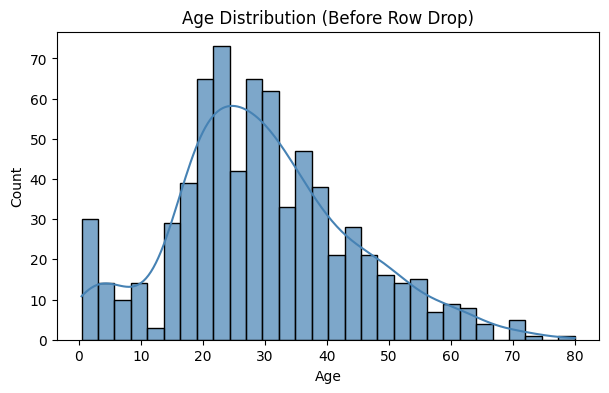

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(
    df['Age'].dropna(),
    bins=30,
    kde=True,
    color='steelblue',
    alpha=0.7
)

plt.title('Age Distribution (Before Row Drop)', fontsize=12)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

**After row-drop**

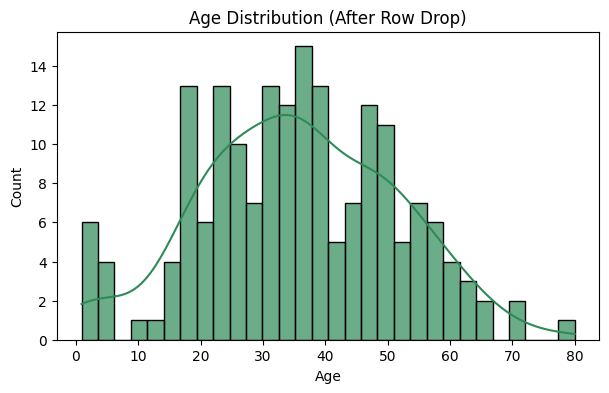

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(
    df_rowdrop['Age'],
    bins=30,
    kde=True,
    color='seagreen',
    alpha=0.7
)

plt.title('Age Distribution (After Row Drop)', fontsize=12)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

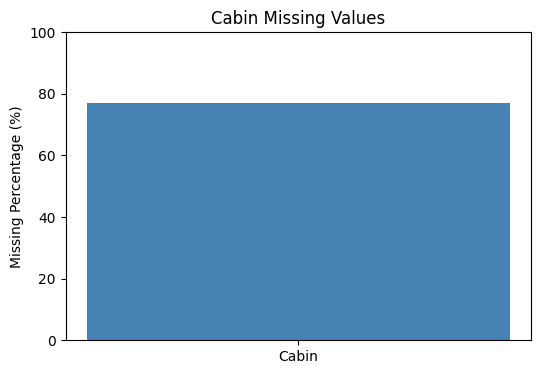

In [ ]:
cabin_missing_pct = df['Cabin'].isnull().mean() * 100

plt.figure(figsize=(6,4))
plt.bar(['Cabin'], [cabin_missing_pct], color='steelblue')
plt.ylabel('Missing Percentage (%)')
plt.title('Cabin Missing Values')
plt.ylim(0, 100)
plt.show()

- Around 77% missing data

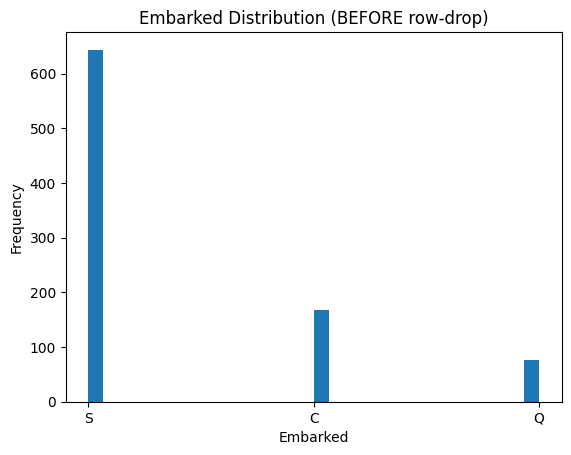

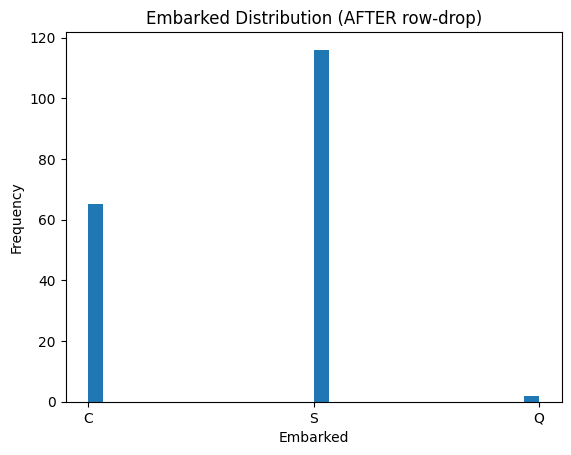

In [ ]:
plt.hist(df['Embarked'].dropna())
plt.title("Embarked Distribution (BEFORE row-drop)")
plt.xlabel("Embarked"); plt.ylabel("Frequency")
plt.show()

# --- AFTER ---
plt.hist(df_rowdrop['Embarked'])  # df_rowdrop me Age me NaN bache nahi
plt.title("Embarked Distribution (AFTER row-drop)")
plt.xlabel("Embarked"); plt.ylabel("Frequency")
plt.show()

# **2. Fill Missing Values (Mean/Median/Mode)**

Quick check: where are the NaNs?

In [ ]:
print("Missing per column (BEFORE):")
print(df.isnull().sum())
print("Total NaNs (BEFORE):", df.isnull().sum().sum())

Missing per column (BEFORE):
PassengerId      0
Survived         0
Pclass           0
Name             0
Gender           0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
Total NaNs (BEFORE): 866


**Make a copy to keep original safe**

In [ ]:
df_fill = df.copy()

**Basic imputations**

- Age (numeric) → median is safer (less affected by outliers)
- Fare (numeric) → median (same reason)
- Embarked (categorical) → mode (most frequent)

In [ ]:
# Median fill for numerics
df_fill['Age']  = df_fill['Age'].fillna(df_fill['Age'].median())

# Mode fill for categoricals
df_fill['Cabin'] = df_fill['Cabin'].fillna(df_fill['Cabin'].mode()[0])
df_fill['Embarked'] = df_fill['Embarked'].fillna(df_fill['Embarked'].mode()[0])

In [ ]:
print("\nMissing per column (AFTER FILL):")
print(df_fill.isnull().sum())
print("Total NaNs (AFTER FILL):", df_fill.isnull().sum().sum())
print("Shape unchanged:", df.shape, "→", df_fill.shape)


Missing per column (AFTER FILL):
PassengerId    0
Survived       0
Pclass         0
Name           0
Gender         0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64
Total NaNs (AFTER FILL): 0
Shape unchanged: (891, 12) → (891, 12)


**A. Age**

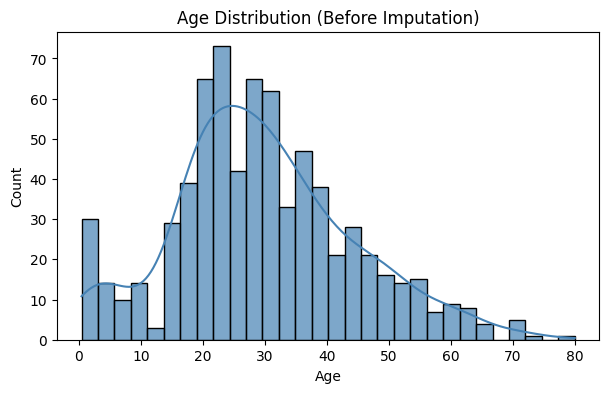

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(
    df['Age'].dropna(),
    bins=30,
    kde=True,
    color='steelblue',
    alpha=0.7
)

plt.title('Age Distribution (Before Imputation)', fontsize=12)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

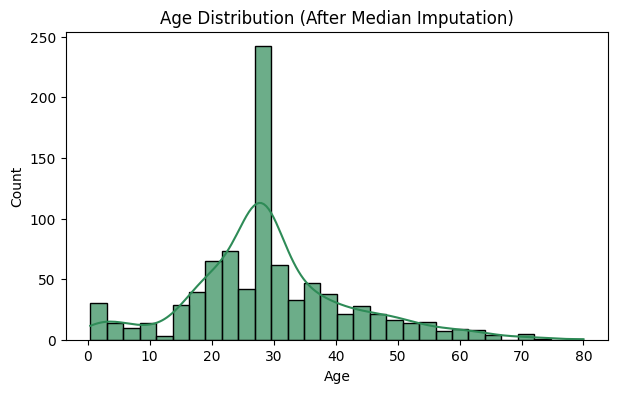

In [ ]:
plt.figure(figsize=(7,4))
sns.histplot(
    df_fill['Age'],
    bins=30,
    kde=True,
    color='seagreen',
    alpha=0.7
)

plt.title('Age Distribution (After Median Imputation)', fontsize=12)
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

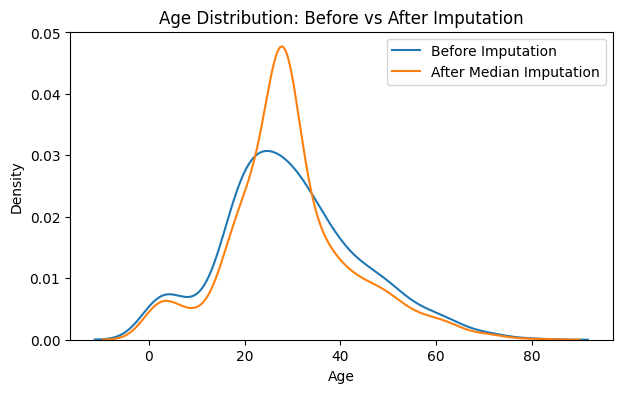

In [ ]:
plt.figure(figsize=(7,4))
sns.kdeplot(df['Age'].dropna(), label='Before Imputation')
sns.kdeplot(df_fill['Age'], label='After Median Imputation')
plt.title('Age Distribution: Before vs After Imputation')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

**B. Cabin**

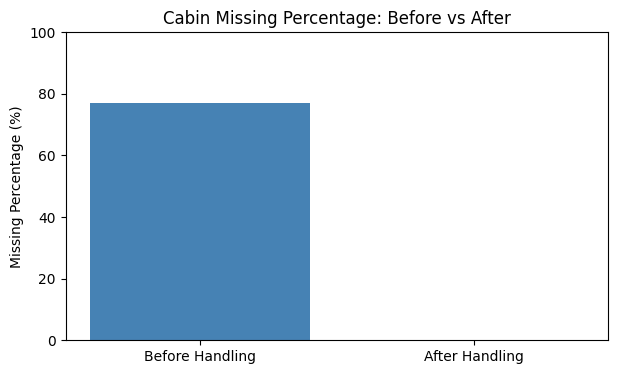

In [ ]:
before_missing = df['Cabin'].isnull().mean() * 100
after_missing = df_fill['Cabin'].isnull().mean() * 100

plt.figure(figsize=(7,4))
plt.bar(
    ['Before Handling', 'After Handling'],
    [before_missing, after_missing],
    color=['steelblue', 'seagreen']
)

plt.title('Cabin Missing Percentage: Before vs After')
plt.ylabel('Missing Percentage (%)')
plt.ylim(0, 100)
plt.show()

In [ ]:
df_fill.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Gender,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# **3. Foward Fill (ffill) and Backward Fill (bfill)**

**1. Forward Fill**

In [ ]:
df_ffill = df.copy()

df_ffill['Embarked'] = df_ffill['Embarked'].ffill()

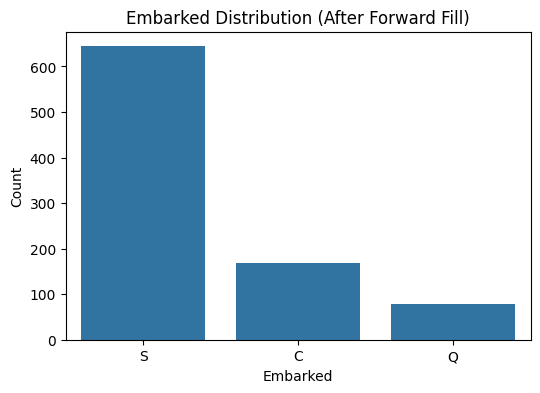

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_ffill, x='Embarked')
plt.title('Embarked Distribution (After Forward Fill)')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.show()

**2. Backward Fill**

In [ ]:
df_bfill = df.copy()

df_bfill['Embarked'] = df_bfill['Embarked'].bfill()

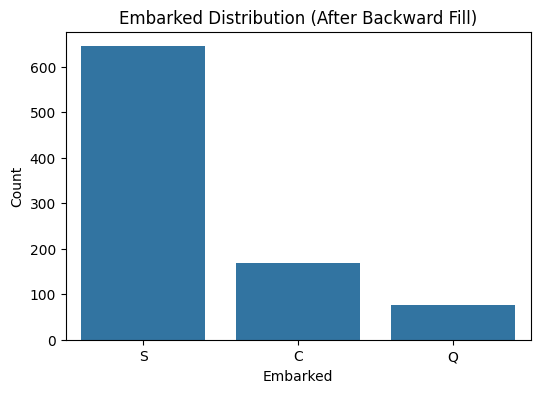

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_bfill, x='Embarked')
plt.title('Embarked Distribution (After Backward Fill)')
plt.xlabel('Embarked')
plt.ylabel('Count')
plt.show()